In [1]:
import numpy as np
import scipy.io
from tqdm import tqdm
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [1]:
# import numpy as np
# import scipy.io
# from tqdm import tqdm

# # Parameters
# N = 800
# Pf = 0.8
# Pn = 0.4
# variance = 0.1
# num_iterations = 50000

# # Symbol sets
# symbol_bpsk = np.array([-1+0j, 1+0j])
# theta1 = np.cos(np.pi/8) + 1j*np.sin(np.pi/8)
# symbol_qpsk = theta1 * np.array([0.7071+0.7071j, -0.7071+0.7071j, 0.7071-0.7071j, -0.7071-0.7071j])
# symbol_8psk = np.array([1, 0.7071+0.7071j, 1j, -0.7071+0.7071j, -1, -0.7071-0.7071j, -1j, 0.7071-0.7071j])
# qam = np.array([-1-1j, 1-1j, 1+1j, -1+1j, -3-1j, -1-3j, 1-3j, 3-1j,
#                 3+1j, 1+3j, -1+3j, -3+1j, -3-3j, 3-3j, 3+3j, -3+3j])
# qam16 = qam.reshape(-1, 1)
# sqrt_mean = np.sqrt(np.mean(np.abs(qam16)**2))
# symbol_16qam = qam16 / sqrt_mean

# # Set of symbols
# setof_symbs = [symbol_bpsk, symbol_qpsk, symbol_8psk, symbol_16qam]

# # Data storage
# true_lbls = np.zeros(num_iterations)
# data_y = np.zeros((num_iterations, N), dtype=complex)
# all_snrs = np.zeros(num_iterations)
# all_h = np.zeros(num_iterations)

# snrs = []
# data_Y = []
# true_Mods = []

# # Simulation loop
# for snr_db in tqdm(range(-10, 21, 2), desc="Processing SNR"):
#     snr = 10**(snr_db/10)
    
#     for iter in tqdm(range(num_iterations), desc="Iterations", leave=False):
#         xr = np.random.randn()
#         yi = np.random.randn()
#         h = np.sqrt(variance * (xr**2 + yi**2))
#         all_h[iter] = h
        
#         i = np.random.randint(0, 4)
#         true_lbls[iter] = i
#         j = np.random.randint(0, 4)
        
#         symb_far = setof_symbs[i]
#         symb_near = setof_symbs[j]
        
#         xf = np.random.choice(symb_far.flatten(), N, replace=True)
#         xn = np.random.choice(symb_near.flatten(), N, replace=True)
        
#         y0 = h * (np.sqrt(Pf) * xf + np.sqrt(Pn) * xn)
#         ps = np.sum(np.abs(y0)**2) / len(y0)
        
#         noisepower = ps / snr
#         z = np.sqrt(noisepower * 0.5) * (np.random.randn(N) + 1j * np.random.randn(N))
#         pn = np.sum(np.abs(z)**2) / len(z)
#         y = y0 + z
        
#         snr_y = ps / pn
#         all_snrs[iter] = snr_y
#         data_y[iter, :] = y
    
#     snrs.extend([snr_db] * num_iterations)
#     data_Y.append(data_y.copy())
#     true_Mods.extend(true_lbls.copy())

# data_Y = np.vstack(data_Y)
# true_Mods = np.array(true_Mods)

# # import h5py

# # # File name
# # file_name = 'dataset_NOMA_N_800_1_2.h5'

# # # Save to HDF5
# # with h5py.File(file_name, 'w') as hf:
# #     hf.create_dataset('data_Y', data=data_Y)
# #     hf.create_dataset('true_Mods', data=true_Mods)
# #     hf.create_dataset('snrs', data=snrs)

# # print(f"Dataset saved as '{file_name}'")


In [3]:
# import h5py

# # File name
# file_name = 'dataset_NOMA_N_800_1_2.h5'

# # Save to HDF5
# with h5py.File(file_name, 'w') as hf:
#     hf.create_dataset('data_Y', data=data_Y)
#     hf.create_dataset('true_Mods', data=true_Mods)
#     hf.create_dataset('snrs', data=snrs)

# print(f"Dataset saved as '{file_name}'")

Dataset saved as 'dataset_NOMA_N_800_1_2.h5'


In [2]:
import h5py

# File name
file_name = 'dataset_NOMA_N_800_1_2.h5'

# Access and print the data
with h5py.File(file_name, 'r') as hf:
    data_Y = hf['data_Y'][:,:200]
    true_Mods = hf['true_Mods'][:]
    snrs = hf['snrs'][:]
    print(f"Shape of data_Y: {data_Y.shape}")
    print(f"Shape of true_Mods: {true_Mods.shape}")
    print(f"Shape of snrs: {snrs.shape}")

# print("data_Y:",data_Y.shape, data_Y[0].shape)
# print("data_Y:", data_Y[0][799])
# print("true_Mods:", true_Mods[:])
# print("snrs:", snrs[:])

Shape of data_Y: (800000, 200)
Shape of true_Mods: (800000,)
Shape of snrs: (800000,)


In [2]:
# print("data_Y:", data_Y[0][:])

#### Shape of data_Y: (800000, 800)
#### Shape of true_Mods: (800000,)
#### Shape of snrs: (800000,)
#### Each signal 800 Point : Total 800000 Signals : both Real & Imaginary in same column
#### shape of data_Y[i] : i X 800

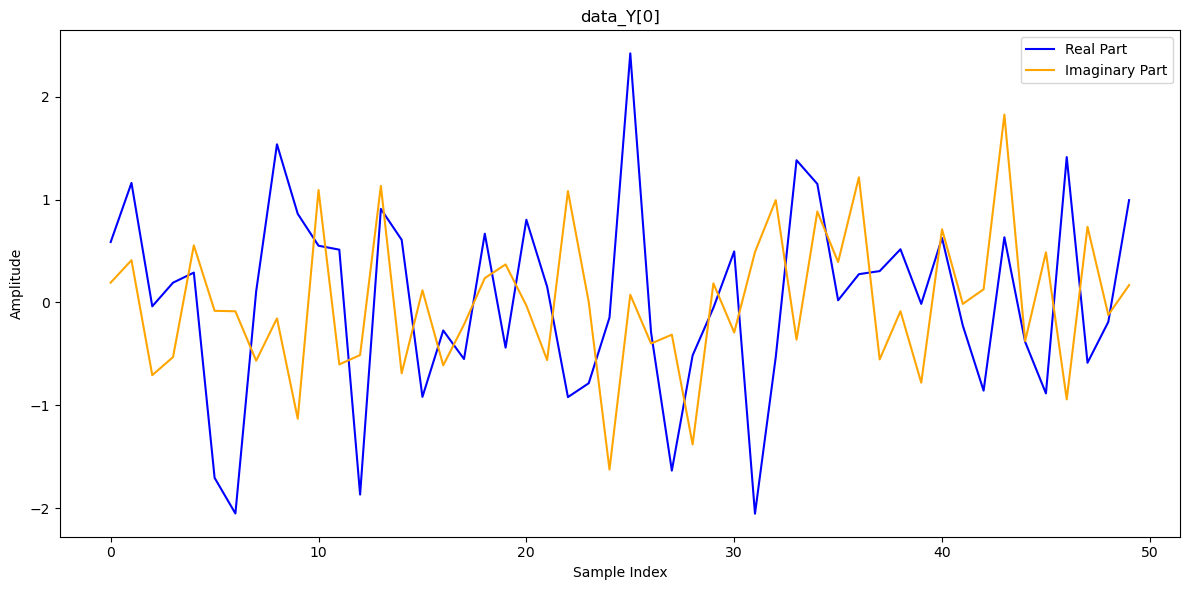

In [3]:
import matplotlib.pyplot as plt

#  Signal
signal = data_Y[0][:50]

plt.figure(figsize=(12, 6))
# plt.subplot(2, 1, 1)
plt.plot(signal.real, label='Real Part', color='blue')
plt.title('Real Part of data_Y[0]')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()

# plt.subplot(2, 1, 2)
plt.plot(signal.imag, label='Imaginary Part', color='orange')
plt.title('Imaginary Part of data_Y[0]')
plt.title('data_Y[0]')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()

# (-0.2525679973170962+0.7865235410144311j)

In [4]:
# Extract features (I and Q components), labels, and SNR levels
snrs = np.array(snrs)

y = np.array(true_Mods)
unique_mods = np.unique(y)
num_classes = len(unique_mods)


X = np.expand_dims(data_Y, axis=-1)
print(f"Shape of X: {X.shape}")

X_real = np.real(X)
X_imag = np.imag(X)
X = np.stack((X_real, X_imag), axis=-1)

X = np.transpose(X, (0, 3, 1, 2))
print(f"Shape of X: {X.shape}")

# # Split data into training and testing sets
# X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(X, y, snrs, test_size=0.4, random_state=42)
X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(X, y, snrs, test_size=0.4)

# # Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Shape of X: (800000, 200, 1)
Shape of X: (800000, 2, 200, 1)
X_train shape: (480000, 2, 200, 1)
X_test shape: (320000, 2, 200, 1)
y_train shape: (480000, 4)
y_test shape: (320000, 4)


# Functional API:

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def modified_residual_block(input_tensor):
    
    main_path = layers.Conv2D(16, (1, 8), activation='relu', padding='same')(input_tensor)
    skip_path = layers.Conv2D(16, (1, 1), activation='relu', padding='same')(input_tensor)
    output = layers.Concatenate()([main_path, skip_path])
    return output

def create_mr_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Define the model
    x = layers.Conv2D(64, (2, 8), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(32, (2, 4), activation='relu', padding='valid')(x)
    x = modified_residual_block(x)
    x = layers.AveragePooling2D(pool_size=(1, 3), strides=1)(x)
    x = layers.Conv2D(16, (1, 3), activation='relu', padding='same')(x)
    x = modified_residual_block(x)
    x = layers.AveragePooling2D(pool_size=(1, 8), strides=1)(x)
    x = layers.Conv2D(8, (1, 3), activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(24, activation='relu')(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model


input_shape = (2, 200, 1)
model = create_mr_cnn(input_shape)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 2, 200, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 2, 200, 64)        │           1,088 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 1, 197, 32)        │          16,416 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 1, 197, 16)        │           4,112 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 1, 197, 16)        │             528 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 1, 197, 32)        │               0 │ conv2d_2[0][0],            │
│                               │                           │                 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d             │ (None, 1, 195, 32)        │               0 │ concatenate[0][0]          │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 1, 195, 16)        │           1,552 │ average_pooling2d[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 1, 195, 16)        │           2,064 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 1, 195, 16)        │             272 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 1, 195, 32)        │               0 │ conv2d_5[0][0],            │
│                               │                           │                 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_1           │ (None, 1, 188, 32)        │               0 │ concatenate_1[0][0]        │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 1, 188, 8)         │             776 │ average_pooling2d_1[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 1504)              │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         192,640 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 222,644 (869.70 KB)

 Trainable params: 222,644 (869.70 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
batch_size = 500
epochs = 12
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))

# Evaluate the model
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 262s 258ms/step - accuracy: 0.4217 - loss: 1.0935 - val_accuracy: 0.5086 - val_loss: 0.9809
Epoch 2/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 242s 252ms/step - accuracy: 0.5374 - loss: 0.9382 - val_accuracy: 0.5752 - val_loss: 0.8806
Epoch 3/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 238s 248ms/step - accuracy: 0.5910 - loss: 0.8573 - val_accuracy: 0.6339 - val_loss: 0.7765
Epoch 4/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 238s 248ms/step - accuracy: 0.6327 - loss: 0.7801 - val_accuracy: 0.6406 - val_loss: 0.7616
Epoch 5/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 241s 251ms/step - accuracy: 0.6501 - loss: 0.7489 - val_accuracy: 0.6574 - val_loss: 0.7325
Epoch 6/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 240s 250ms/step - accuracy: 0.6596 - loss: 0.7296 - val_accuracy: 0.6600 - val_loss: 0.7236
Epoch 7/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 245s 255ms/step - accuracy: 0.6719 - loss: 0.7039 - val_accuracy: 0.6698 - val_loss: 0.7048
Epoch 8/20
960/960 ━━━━━━━━━━━━━━━━━━━━ 251s 261ms/step - accuracy: 0.6731 -

In [7]:
# Make predictions
y_pred = model.predict(X_test)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 44s 4ms/step


In [8]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
# for i in range(len(y_true)):
#     print(y_true[i],y_pred_classes[i])

Normalized Confusion Matrix:
[[0.90527172 0.00812957 0.03104246 0.05555625]
 [0.08435168 0.45527621 0.20165774 0.25871438]
 [0.08532759 0.03262196 0.57662425 0.3054262 ]
 [0.09467463 0.02579417 0.15413896 0.72539223]]


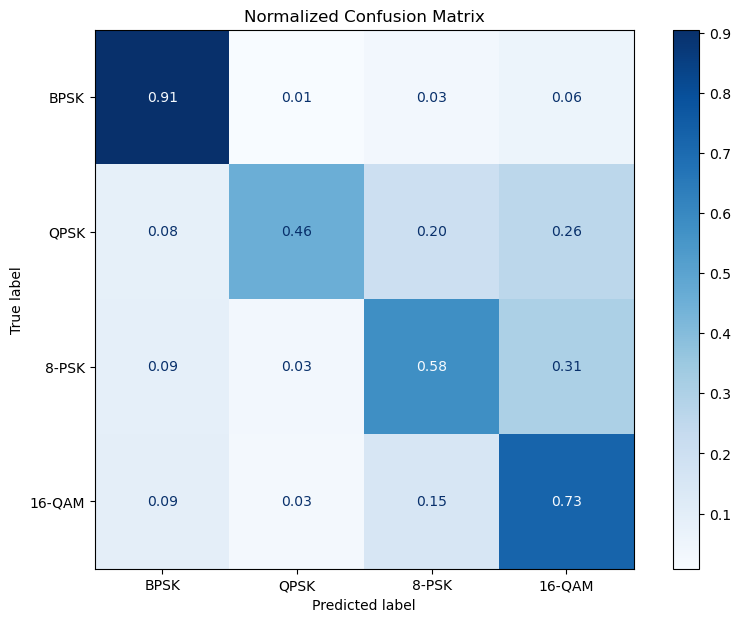

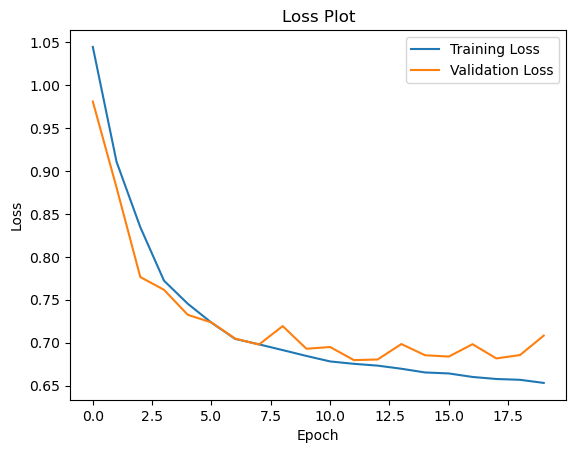

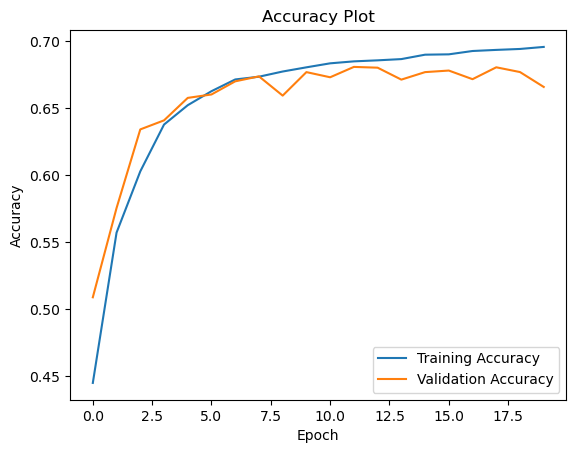

In [9]:
modulation_mapping = {
    0: 'BPSK',
    1: 'QPSK',
    2: '8-PSK',
    3: '16-QAM'
}
# Get the class labels in the order of modulation_mapping
labels = [modulation_mapping[i] for i in range(num_classes)]

def plot_normalized_confusion_matrix(cm, labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(10, 7))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")
    plt.title('Normalized Confusion Matrix')
    plt.show()

cm = confusion_matrix(y_true, y_pred_classes, labels=np.arange(num_classes))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Print the normalized confusion matrix
print("Normalized Confusion Matrix:")
print(cm_normalized)
plot_normalized_confusion_matrix(cm_normalized, labels)


# Plot loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.legend()
plt.show()


# Plot accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Plot')
plt.legend()
plt.show()

633/633 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


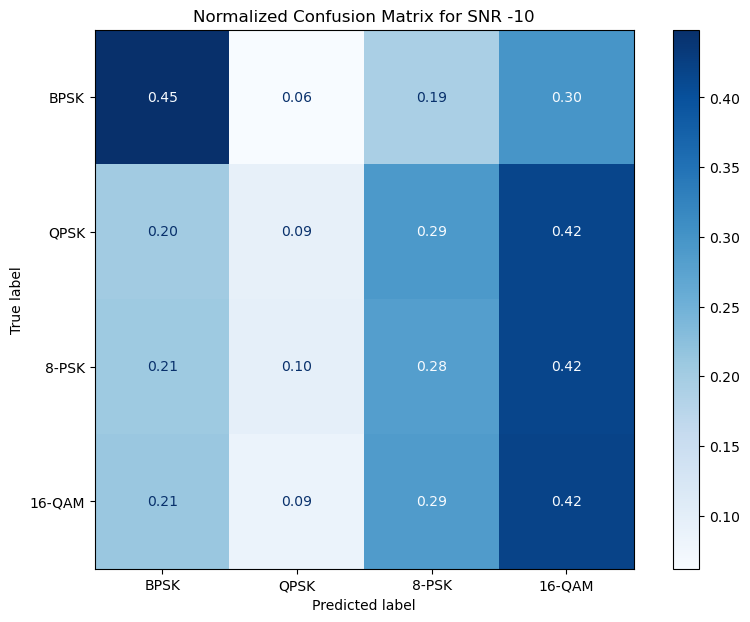

628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


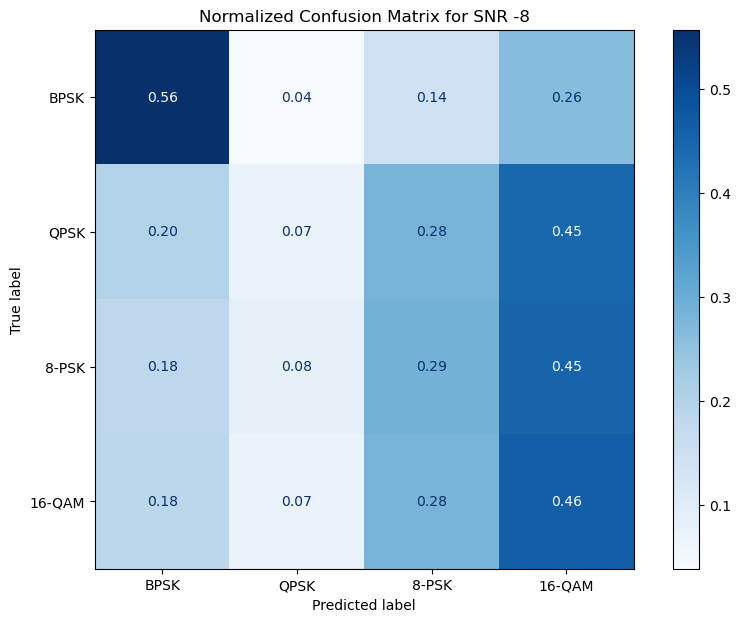

630/630 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


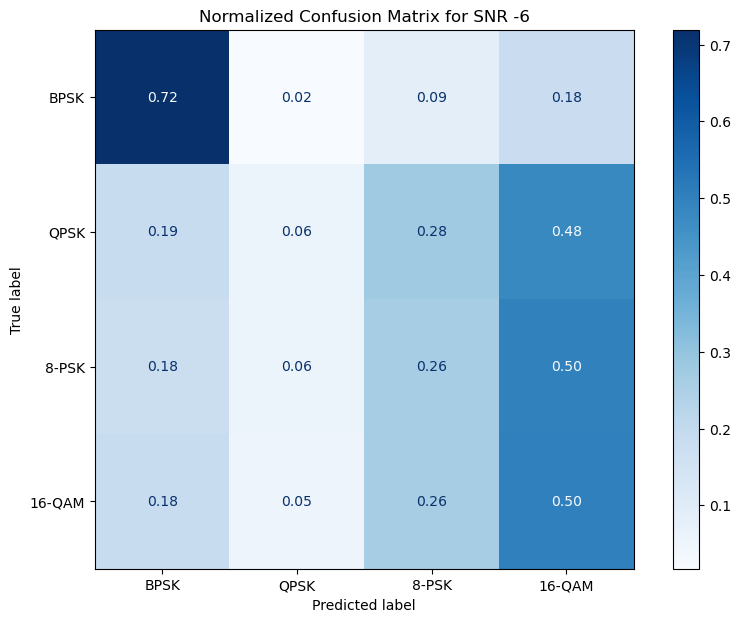

626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


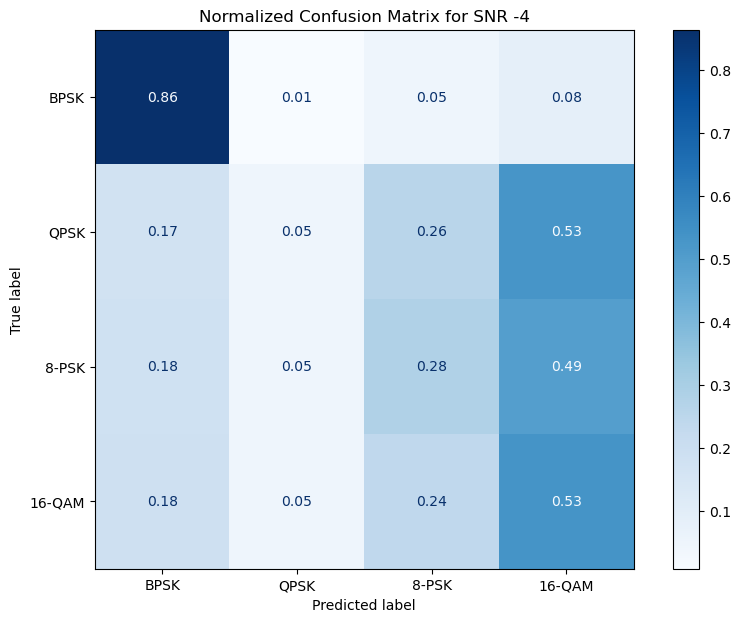

619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


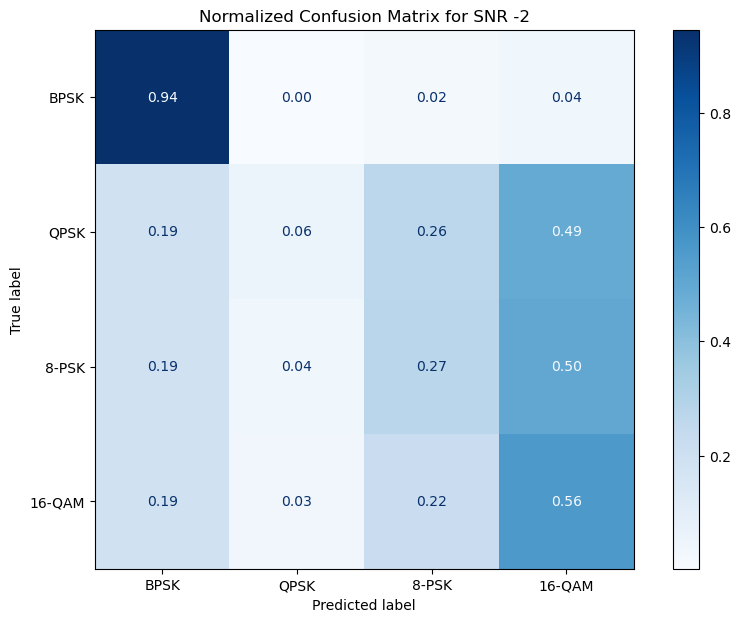

623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


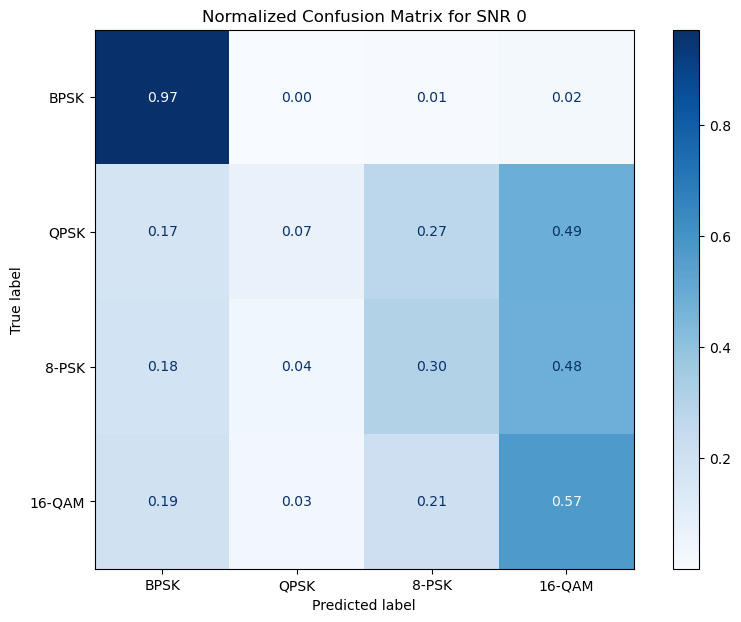

628/628 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


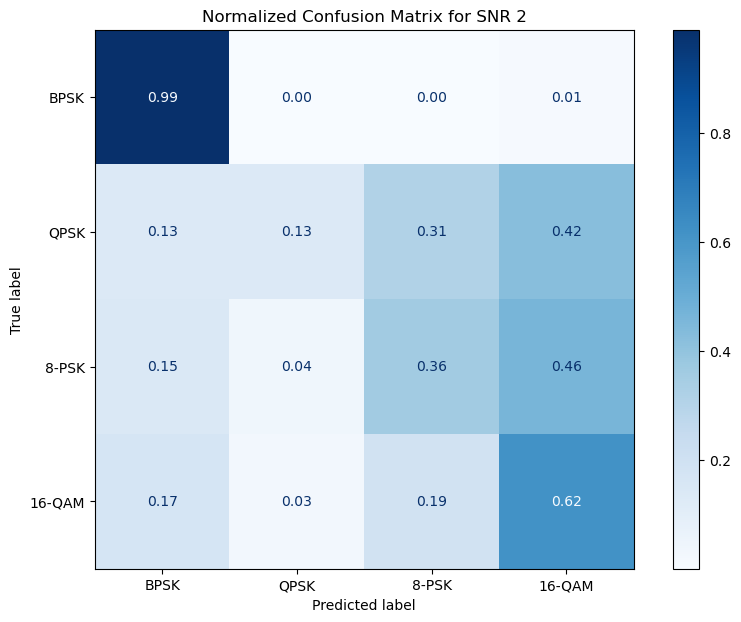

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


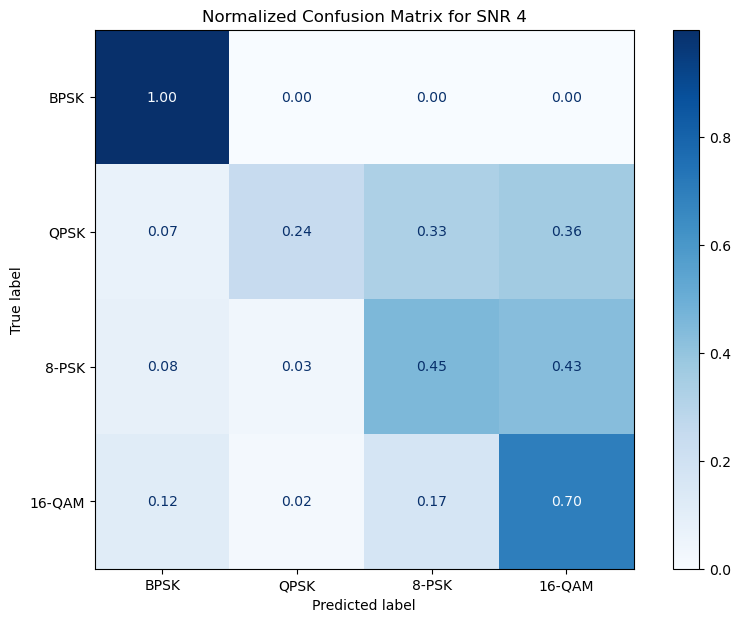

629/629 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


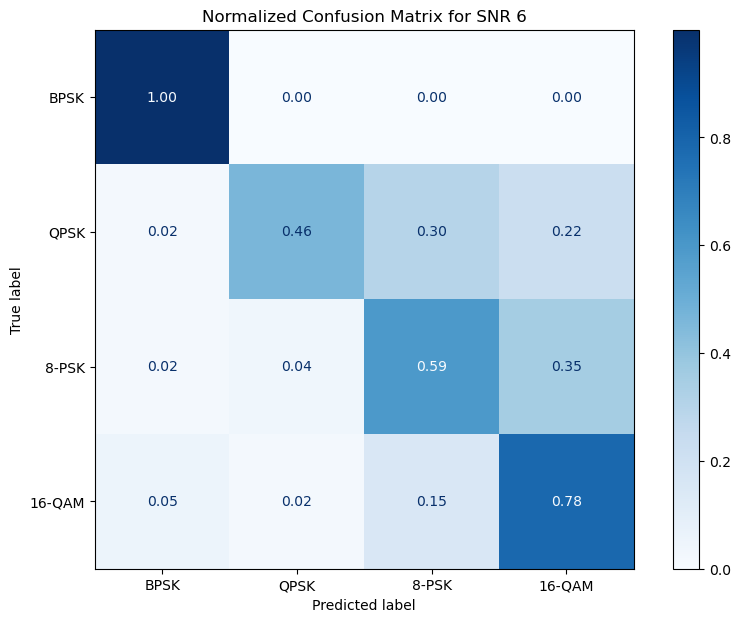

622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


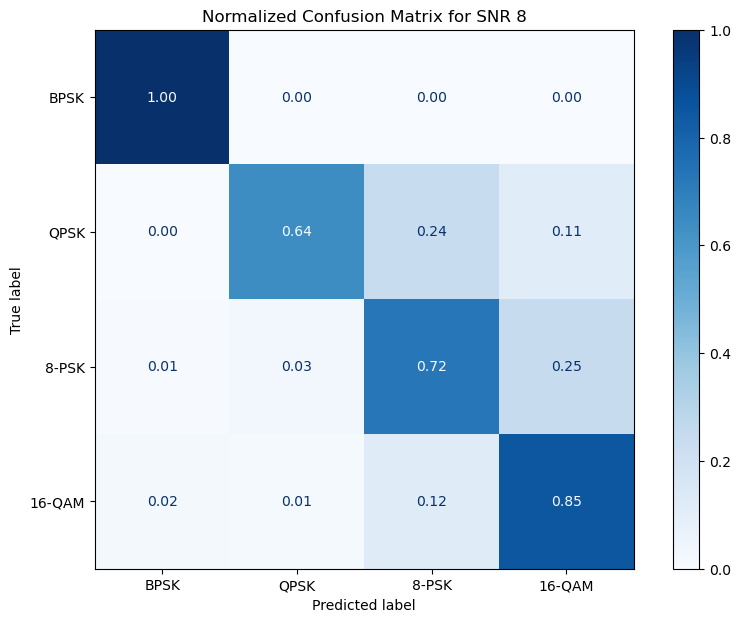

628/628 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


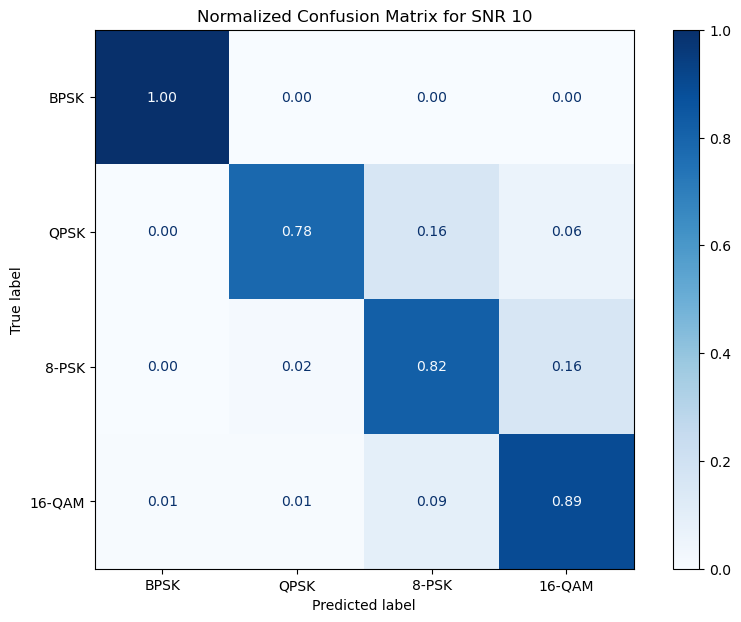

622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


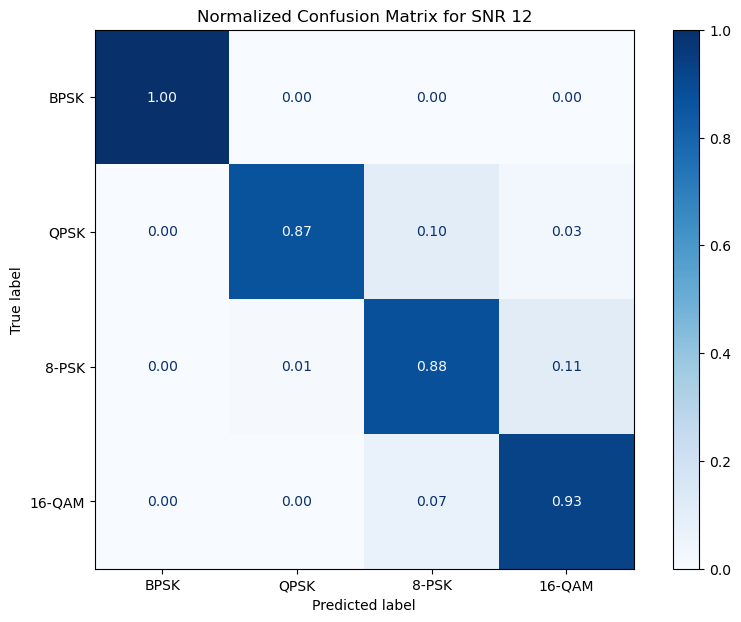

620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


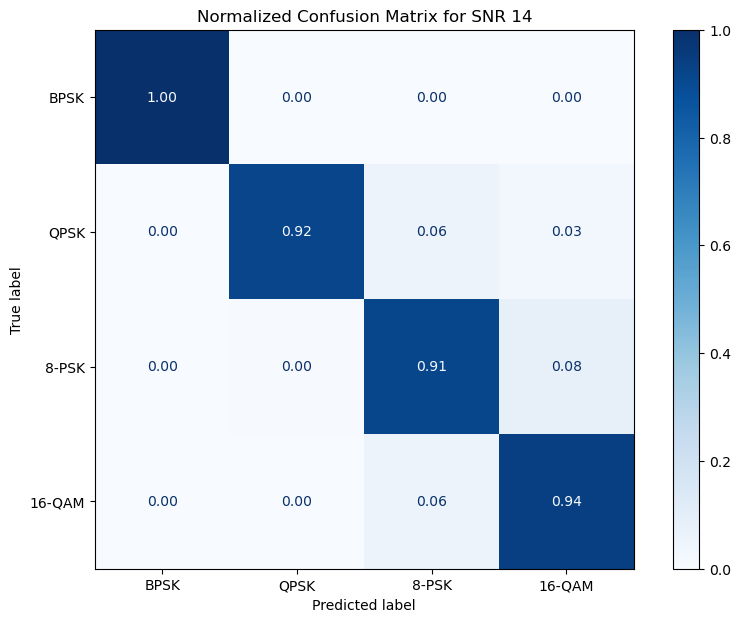

624/624 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


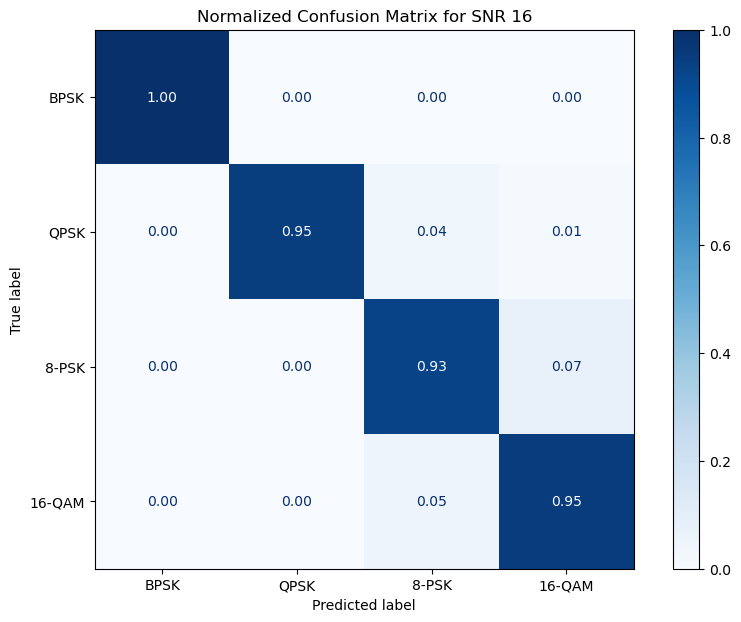

627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


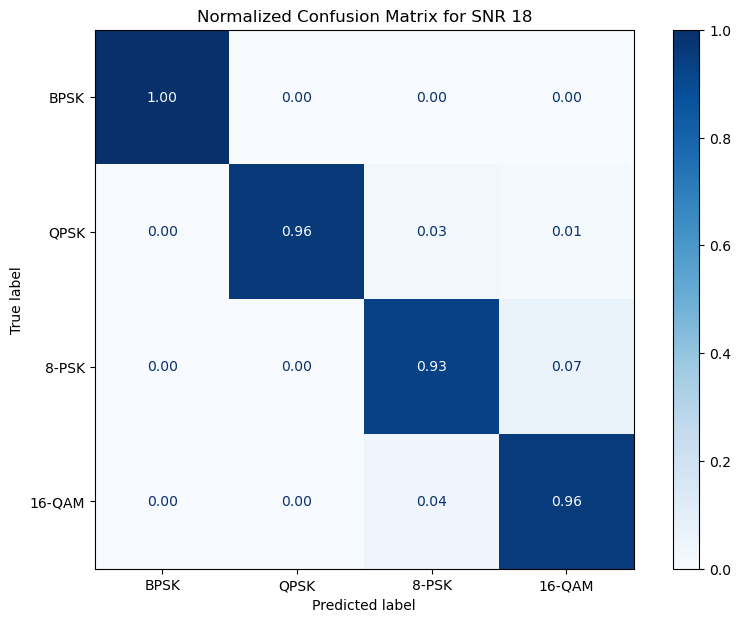

624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


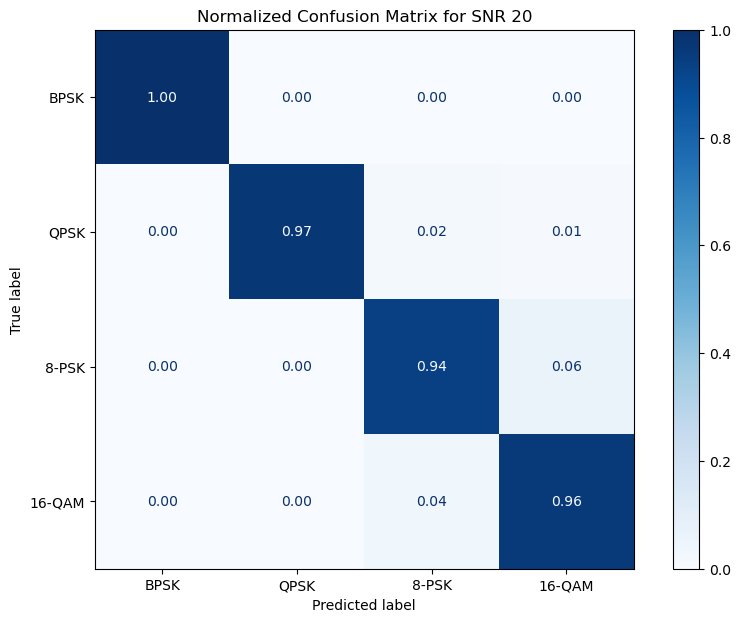

In [10]:
# Evaluate and plot confusion matrix and accuracy for each SNR level
snr_levels = np.unique(snr_test)
accuracy_per_snr = []

for snr_level in snr_levels:
    def plot_normalized_confusion_matrix(cm, labels, title):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(10, 7))
        disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")
        plt.title(title)
        plt.show()
        
    # Get data for this SNR level
    snr_indices = np.where(snr_test == snr_level)
    X_snr = X_test[snr_indices]
    y_snr_true = y_true[snr_indices]
    y_snr_test = y_test[snr_indices]

    # Make predictions
    y_snr_pred = model.predict(X_snr)
    y_snr_pred_classes = np.argmax(y_snr_pred, axis=1)

    # Calculate confusion matrix for this SNR level
    snr_conf_matrix = confusion_matrix(y_snr_true, y_snr_pred_classes, labels=np.arange(num_classes))
    
    # Normalize the confusion matrix by row (true labels)
    snr_conf_matrix_normalized = snr_conf_matrix.astype('float') / snr_conf_matrix.sum(axis=1)[:, np.newaxis]

    plot_normalized_confusion_matrix(snr_conf_matrix_normalized, labels, f'Normalized Confusion Matrix for SNR {snr_level}')

    # Calculate accuracy
    accuracy = np.sum(y_snr_pred_classes == y_snr_true) / len(y_snr_true)
    accuracy_per_snr.append(accuracy)

# Save Model

In [11]:
import pickle
import tensorflow as tf
from tensorflow.keras.models import model_from_json

# Save the model architecture as JSON
model_json = model.to_json()
with open("mr_cnn_model.json", "w") as json_file:
    json_file.write(model_json)

# Save the model weights using pickle
with open("mr_cnn_weights.pkl", "wb") as weights_file:
    pickle.dump(model.get_weights(), weights_file)

print("Model architecture and weights saved successfully.")


Model architecture and weights saved successfully.


In [12]:
# Save the model in HDF5 format
model.save("mr_cnn_model.h5")

# Load the model
loaded_model = tf.keras.models.load_model("mr_cnn_model.h5")

print("Model saved and loaded successfully using .h5 format.")

Model saved and loaded successfully using .h5 format.


# Load Model

In [13]:
import pickle
import tensorflow as tf
from tensorflow.keras.models import model_from_json

# Load the model architecture
with open("mr_cnn_model.json", "r") as json_file:
    loaded_model_json = json_file.read()
loaded_model = model_from_json(loaded_model_json)

# Load the weights
with open("mr_cnn_weights.pkl", "rb") as weights_file:
    loaded_weights = pickle.load(weights_file)
loaded_model.set_weights(loaded_weights)

# Compile the model
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Model loaded successfully.")

# Compile the model
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Show model structure
loaded_model.summary()

Model loaded successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 2, 200, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 2, 200, 64)        │           1,088 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 1, 197, 32)        │          16,416 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 1, 197, 16)        │           4,112 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 1, 197, 16)        │             528 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 1, 197, 32)        │               0 │ conv2d_2[0][0],            │
│                               │                           │                 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d             │ (None, 1, 195, 32)        │               0 │ concatenate[0][0]          │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 1, 195, 16)        │           1,552 │ average_pooling2d[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 1, 195, 16)        │           2,064 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 1, 195, 16)        │             272 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 1, 195, 32)        │               0 │ conv2d_5[0][0],            │
│                               │                           │                 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_1           │ (None, 1, 188, 32)        │               0 │ concatenate_1[0][0]        │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 1, 188, 8)         │             776 │ average_pooling2d_1[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 1504)              │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         192,640 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 222,644 (869.70 KB)

 Trainable params: 222,644 (869.70 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

# Load the model
model = load_model('mr_cnn_model.h5')

# Print the model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 2, 200, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 2, 200, 64)        │           1,088 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 1, 197, 32)        │          16,416 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 1, 197, 16)        │           4,112 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 1, 197, 16)        │             528 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 1, 197, 32)        │               0 │ conv2d_2[0][0],            │
│                               │                           │                 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d             │ (None, 1, 195, 32)        │               0 │ concatenate[0][0]          │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 1, 195, 16)        │           1,552 │ average_pooling2d[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 1, 195, 16)        │           2,064 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 1, 195, 16)        │             272 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 1, 195, 32)        │               0 │ conv2d_5[0][0],            │
│                               │                           │                 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_1           │ (None, 1, 188, 32)        │               0 │ concatenate_1[0][0]        │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 1, 188, 8)         │             776 │ average_pooling2d_1[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 1504)              │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         192,640 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 222,646 (869.71 KB)

 Trainable params: 222,644 (869.70 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

# Filter Extraction

In [15]:
import tensorflow as tf
import numpy as np
import os
import pandas as pd

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")
print("Model loaded successfully.")

# Create a folder to save filter data
save_folder = "CNN_Filters"
os.makedirs(save_folder, exist_ok=True)

# Iterate through model layers
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        filters, biases = layer.get_weights()
        num_filters = filters.shape[-1]
        filter_size = filters.shape[0] * filters.shape[1] * filters.shape[2]  # Flatten each filter
        
        # Reshape filters to have one column per filter and stacked row-wise
        filter_data = filters.reshape(-1, num_filters)
        
        # Convert filter to DataFrame
        df = pd.DataFrame(filter_data)
        
        # Save to Excel
        file_name = os.path.join(save_folder, f"{layer.name}_filters.xlsx")
        df.to_excel(file_name, index=False)
        print(f"Saved all filters of layer {layer.name} to {file_name}")

print("All filters extracted and saved successfully.")

Model loaded successfully.
Saved all filters of layer conv2d to CNN_Filters\conv2d_filters.xlsx
Saved all filters of layer conv2d_1 to CNN_Filters\conv2d_1_filters.xlsx
Saved all filters of layer conv2d_2 to CNN_Filters\conv2d_2_filters.xlsx
Saved all filters of layer conv2d_3 to CNN_Filters\conv2d_3_filters.xlsx
Saved all filters of layer conv2d_4 to CNN_Filters\conv2d_4_filters.xlsx
Saved all filters of layer conv2d_5 to CNN_Filters\conv2d_5_filters.xlsx
Saved all filters of layer conv2d_6 to CNN_Filters\conv2d_6_filters.xlsx
Saved all filters of layer conv2d_7 to CNN_Filters\conv2d_7_filters.xlsx
All filters extracted and saved successfully.


In [16]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")
print("Model loaded successfully.")

# Create a folder to store the extracted weights and biases
save_folder = "Dense_Layer_Weights_Biases"
os.makedirs(save_folder, exist_ok=True)

# Iterate through model layers to find dense layers
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        weights, biases = layer.get_weights()

        # Save weights to an Excel file
        weights_file = os.path.join(save_folder, f"{layer.name}_weights.xlsx")
        weights_df = pd.DataFrame(weights)
        weights_df.to_excel(weights_file, index=False)
        print(f"Saved weights of layer {layer.name} to {weights_file}")

        # Save biases to an Excel file
        biases_file = os.path.join(save_folder, f"{layer.name}_biases.xlsx")
        biases_df = pd.DataFrame(biases)
        biases_df.to_excel(biases_file, index=False)
        print(f"Saved biases of layer {layer.name} to {biases_file}")

print("All dense layer weights and biases extracted and saved successfully.")


Model loaded successfully.
Saved weights of layer dense to Dense_Layer_Weights_Biases\dense_weights.xlsx
Saved biases of layer dense to Dense_Layer_Weights_Biases\dense_biases.xlsx
Saved weights of layer dense_1 to Dense_Layer_Weights_Biases\dense_1_weights.xlsx
Saved biases of layer dense_1 to Dense_Layer_Weights_Biases\dense_1_biases.xlsx
Saved weights of layer dense_2 to Dense_Layer_Weights_Biases\dense_2_weights.xlsx
Saved biases of layer dense_2 to Dense_Layer_Weights_Biases\dense_2_biases.xlsx
All dense layer weights and biases extracted and saved successfully.


In [33]:
# import tensorflow as tf
# import os
# import numpy as np
# import pandas as pd

# # Load the trained model
# model = tf.keras.models.load_model("mr_cnn_model.h5")
# print("Model loaded successfully.")

# # Create folder to save filters
# save_folder = "CNN_Filters_4"
# os.makedirs(save_folder, exist_ok=True)

# # Loop through each layer to find Conv2D layers and extract filters + bias
# for i, layer in enumerate(model.layers):
#     if isinstance(layer, tf.keras.layers.Conv2D):
#         filters, biases = layer.get_weights()
#         print(f"Layer {i} ({layer.name}) - Filters shape: {filters.shape}, Biases shape: {biases.shape}")

#         num_filters = filters.shape[-1]  # Number of output channels
#         num_channels = filters.shape[-2]  # Number of input channels

#         # Create subfolder for this layer
#         layer_folder = os.path.join(save_folder, f"{layer.name}")
#         os.makedirs(layer_folder, exist_ok=True)

#         # Save each filter and bias in individual Excel files
#         for f in range(num_filters):
#             data = []
#             for c in range(num_channels):
#                 filter_matrix = filters[:, :, c, f]
#                 df = pd.DataFrame(filter_matrix)
#                 df.columns = [f"Ch{c+1}_Col{j+1}" for j in range(df.shape[1])]
#                 data.append(df)

#             result = pd.concat(data, axis=1)
#             bias_value = biases[f]

#             # Save filter + bias together
#             bias_row = pd.DataFrame([[f"Bias: {bias_value}"] + [""] * (result.shape[1] - 1)],
#                                     columns=result.columns)
#             result_with_bias = pd.concat([result, bias_row], axis=0)
#             filter_file = os.path.join(layer_folder, f"{layer.name}_filter_{f+1}.xlsx")
#             result_with_bias.to_excel(filter_file, index=False)
#             print(f"Saved filter {f+1} with bias of layer {layer.name} to {filter_file}")

#             # Save bias separately
#             bias_df = pd.DataFrame({"Bias_Value": [bias_value]})
#             bias_file = os.path.join(layer_folder, f"{layer.name}_bias_{f+1}.xlsx")
#             bias_df.to_excel(bias_file, index=False)
#             print(f"Saved bias {f+1} of layer {layer.name} to {bias_file}")



import tensorflow as tf
import os
import numpy as np
import pandas as pd

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")
print("Model loaded successfully.")

# Create folder to save filters
save_folder = "CNN_Filters_4"
os.makedirs(save_folder, exist_ok=True)

# List to store all biases
all_biases_data = []

# Loop through each layer to find Conv2D layers and extract filters + bias
for i, layer in enumerate(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        filters, biases = layer.get_weights()
        print(f"Layer {i} ({layer.name}) - Filters shape: {filters.shape}, Biases shape: {biases.shape}")

        num_filters = filters.shape[-1]  # Number of output channels
        num_channels = filters.shape[-2]  # Number of input channels

        # Save each filter and bias in individual Excel files
        for f in range(num_filters):
            data = []
            for c in range(num_channels):
                filter_matrix = filters[:, :, c, f]
                df = pd.DataFrame(filter_matrix)
                df.columns = [f"Ch{c+1}_Col{j+1}" for j in range(df.shape[1])]
                data.append(df)

            result = pd.concat(data, axis=1)
            bias_value = biases[f]
            bias_row = pd.DataFrame([[f"Bias: {bias_value}"] + [""] * (result.shape[1] - 1)],
                                    columns=result.columns)
            result_with_bias = pd.concat([result, bias_row], axis=0)

            file_path = os.path.join(save_folder, f"{layer.name}_filter_{f+1}.xlsx")
            result_with_bias.to_excel(file_path, index=False)
            print(f"Saved filter {f+1} with bias of layer {layer.name} to {file_path}")

        # Collect all biases for this layer
        bias_df = pd.DataFrame({
            "Layer": [layer.name] * num_filters,
            "Filter_Index": list(range(1, num_filters + 1)),
            "Bias_Value": biases
        })
        all_biases_data.append(bias_df)

# Combine and save all biases to one Excel file
all_biases_df = pd.concat(all_biases_data, ignore_index=True)
bias_file_path = os.path.join(save_folder, "all_biases.xlsx")
all_biases_df.to_excel(bias_file_path, index=False)
print(f"Saved all biases to {bias_file_path}")



Model loaded successfully.
Layer 1 (conv2d) - Filters shape: (2, 8, 1, 64), Biases shape: (64,)
Saved filter 1 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_1.xlsx
Saved filter 2 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_2.xlsx
Saved filter 3 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_3.xlsx
Saved filter 4 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_4.xlsx
Saved filter 5 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_5.xlsx
Saved filter 6 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_6.xlsx
Saved filter 7 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_7.xlsx
Saved filter 8 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_8.xlsx
Saved filter 9 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_9.xlsx
Saved filter 10 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_10.xlsx
Saved filter 11 with bias of layer conv2d to CNN_Filters_4\conv2d_filter_11.xlsx
Saved filter 12 with bias of la

# Filter into separete unit

In [19]:
import pandas as pd
import os

# Load the Excel file
df = pd.read_excel('conv2d_filters.xlsx')

# Create the output folder named '64'
output_folder = '64'
os.makedirs(output_folder, exist_ok=True)

# Iterate over each column and save to a separate Excel file
for i, column in enumerate(df.columns):
    file_name = f'filter_{i+1}.xlsx'  # file names: filter_1.xlsx, filter_2.xlsx, ...
    file_path = os.path.join(output_folder, file_name)

    # Create a DataFrame with just that column
    single_col_df = df[[column]]

    # Save to Excel file
    single_col_df.to_excel(file_path, index=False)

print("Done: All 64 Excel files saved inside the '64' folder.")

Done: All 64 Excel files saved inside the '64' folder.


# Binary Conversion

In [20]:
# FILTERS
import pandas as pd
import numpy as np
import os

# Define constants
dataWidth = 16  # Total width in bits
intWidth = 4    # Integer width in bits
fracWidth = dataWidth - intWidth  # Fractional width
outputPath = "./"  # Path to save the output files
headerPath = "./"

# DtoB function for two's complement conversion
def DtoB(num, dataWidth, fracBits):  
    if num >= 0:
        num = num * (2**fracBits)
        num = int(num)
        d = num
    else:
        num = -num
        num = num * (2**fracBits)  # Number of fractional bits
        num = int(num)
        if num == 0:
            d = 0
        else:
            d = 2**dataWidth - num
    return d

# Convert the values in the dataframe to binary and save to Excel
def convert_dataframe_to_binary(df, dataWidth, fracWidth):
    binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements
    return binary_df

filter_files = [
    "conv2d_filters.xlsx",
    "conv2d_1_filters.xlsx",
    "conv2d_2_filters.xlsx",
    "conv2d_3_filters.xlsx",
    "conv2d_4_filters.xlsx",
    "conv2d_5_filters.xlsx",
    "conv2d_6_filters.xlsx",
    "conv2d_7_filters.xlsx",
]

# Convert each file and save the binary data to a new Excel file
def convert_and_save_filters(filter_files):
    for filter_file in filter_files:
        # Read the filter values from the Excel file
        df = pd.read_excel(filter_file)
        
        # Convert the filter values to binary
        binary_df = convert_dataframe_to_binary(df, dataWidth, fracWidth)
        
        # Modify the output file name
        output_file = os.path.join(outputPath, f"binary_{filter_file}")
        
        # Save the binary DataFrame to a new Excel file
        binary_df.to_excel(output_file, index=False)
        print(f"Converted values saved to {output_file}")

# Convert and save all filters
convert_and_save_filters(filter_files)


C:\Users\debab\AppData\Local\Temp\ipykernel_7108\1604679061.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements


Converted values saved to ./binary_conv2d_filters.xlsx


C:\Users\debab\AppData\Local\Temp\ipykernel_7108\1604679061.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements


Converted values saved to ./binary_conv2d_1_filters.xlsx
Converted values saved to ./binary_conv2d_2_filters.xlsx


C:\Users\debab\AppData\Local\Temp\ipykernel_7108\1604679061.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements
C:\Users\debab\AppData\Local\Temp\ipykernel_7108\1604679061.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements


Converted values saved to ./binary_conv2d_3_filters.xlsx
Converted values saved to ./binary_conv2d_4_filters.xlsx


C:\Users\debab\AppData\Local\Temp\ipykernel_7108\1604679061.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements
C:\Users\debab\AppData\Local\Temp\ipykernel_7108\1604679061.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements


Converted values saved to ./binary_conv2d_5_filters.xlsx
Converted values saved to ./binary_conv2d_6_filters.xlsx
Converted values saved to ./binary_conv2d_7_filters.xlsx


C:\Users\debab\AppData\Local\Temp\ipykernel_7108\1604679061.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements
C:\Users\debab\AppData\Local\Temp\ipykernel_7108\1604679061.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))  # Apply DtoB to all elements


In [34]:
# BIAS
import pandas as pd

# Fixed-point parameters
dataWidth = 16
intWidth = 4
fracWidth = dataWidth - intWidth

# Function to convert decimal to 4.12 fixed-point two's complement binary
def DtoB(num, dataWidth, fracBits):  
    if num >= 0:
        num = int(num * (2**fracBits))
        d = num
    else:
        num = -int(abs(num) * (2**fracBits))
        d = (1 << dataWidth) + num  # Two's complement
    return d

# Read the biases file
df = pd.read_excel("all_biases.xlsx")

# Convert third column to binary and store in new column
df["Binary_4.12"] = df.iloc[:, 2].apply(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))

# Save the full DataFrame with the new column
df.to_excel("binary_all_biases.xlsx", index=False)
print("Converted and saved to binary_all_biases.xlsx")


Converted and saved to binary_all_biases.xlsx


In [18]:
def fixed_point_4_12_to_decimal(binary_str):
    """
    Converts a 4.12 fixed-point binary string to a signed decimal value.
    Assumes input is a 16-bit string: 4 bits integer + 12 bits fraction.
    """
    if len(binary_str) != 16:
        raise ValueError("Input must be a 16-bit binary string.")

    # Convert the full binary string to an integer
    raw = int(binary_str, 2)

    # Check for sign bit (first bit is 1 if negative)
    if binary_str[0] == '1':
        raw -= 1 << 16  # Two's complement correction

    # Divide by 2^12 to account for 12 fractional bits
    return raw / (1 << 12)


# Example usage:
binary_input = "1111111111110110"  # You can change this
decimal_value = fixed_point_4_12_to_decimal(binary_input)
print(f"Binary: {binary_input} → Decimal: {decimal_value}")
print(8*16)

Binary: 1111111111110110 → Decimal: -0.00244140625
128


# After binary

In [29]:
# FILTER
import pandas as pd

def save_filters_to_mif(file_name):
    # Load the Excel file and skip the first row
    excel_data = pd.read_excel(file_name, header=None, skiprows=1)
    
    # Iterate over each column (filter)
    for i, column in enumerate(excel_data.columns):
        filter_data = excel_data[column]
        
        # Prepare MIF content with only the binary values
        mif_content = ""
        for value in filter_data:
            # Convert values to binary (assume values are 0 or 1)
            binary_value = str(int(value))
            mif_content += f"{binary_value}\n"
        
        # Write to a MIF file
        mif_file_name = f"f_8_{i}.mif"
        with open(mif_file_name, 'w') as mif_file:
            mif_file.write(mif_content)
        print(f"Generated {mif_file_name}")

# Usage
save_filters_to_mif("binary_conv2d_7_filters.xlsx")


Generated f_8_0.mif
Generated f_8_1.mif
Generated f_8_2.mif
Generated f_8_3.mif
Generated f_8_4.mif
Generated f_8_5.mif
Generated f_8_6.mif
Generated f_8_7.mif


In [35]:
import pandas as pd
import os

# Load Excel file
df = pd.read_excel("binary_all_biases.xlsx")

# Output folder
output_dir = "separate_bias_files"
os.makedirs(output_dir, exist_ok=True)

# Process each row
for idx, row in df.iterrows():
    try:
        col1 = str(row[0]).strip()  # Layer name or ID
        col2 = str(row[1]).strip()  # Filter number or ID
        binary_value = str(row[3]).strip()  # Binary string (should be 16-bit)

        # File name: merge col1 and col2
        filename = f"{col1}_{col2}.mif"
        filepath = os.path.join(output_dir, filename)

        # Write binary value to file (just one line)
        with open(filepath, 'w') as f:
            f.write(binary_value + "\n")

        print(f"Saved: {filename}")

    except Exception as e:
        print(f"Error at row {idx}: {e}")


Saved: conv2d_1.mif
Saved: conv2d_2.mif
Saved: conv2d_3.mif
Saved: conv2d_4.mif
Saved: conv2d_5.mif
Saved: conv2d_6.mif
Saved: conv2d_7.mif
Saved: conv2d_8.mif
Saved: conv2d_9.mif
Saved: conv2d_10.mif
Saved: conv2d_11.mif
Saved: conv2d_12.mif
Saved: conv2d_13.mif
Saved: conv2d_14.mif
Saved: conv2d_15.mif
Saved: conv2d_16.mif
Saved: conv2d_17.mif
Saved: conv2d_18.mif
Saved: conv2d_19.mif
Saved: conv2d_20.mif
Saved: conv2d_21.mif
Saved: conv2d_22.mif
Saved: conv2d_23.mif
Saved: conv2d_24.mif
Saved: conv2d_25.mif
Saved: conv2d_26.mif
Saved: conv2d_27.mif
Saved: conv2d_28.mif
Saved: conv2d_29.mif
Saved: conv2d_30.mif
Saved: conv2d_31.mif
Saved: conv2d_32.mif
Saved: conv2d_33.mif
Saved: conv2d_34.mif
Saved: conv2d_35.mif
Saved: conv2d_36.mif
Saved: conv2d_37.mif
Saved: conv2d_38.mif
Saved: conv2d_39.mif
Saved: conv2d_40.mif
Saved: conv2d_41.mif
Saved: conv2d_42.mif
Saved: conv2d_43.mif
Saved: conv2d_44.mif
Saved: conv2d_45.mif
Saved: conv2d_46.mif
Saved: conv2d_47.mif
Saved: conv2d_48.mif
S

C:\Users\debab\AppData\Local\Temp\ipykernel_7108\2887816595.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col1 = str(row[0]).strip()  # Layer name or ID
C:\Users\debab\AppData\Local\Temp\ipykernel_7108\2887816595.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  col2 = str(row[1]).strip()  # Filter number or ID
C:\Users\debab\AppData\Local\Temp\ipykernel_7108\2887816595.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  

# Checking Biases and FIlters

In [89]:
import numpy as np
import tensorflow as tf
import pandas as pd

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")  # Update with correct path

# Get the first convolutional layer (assuming it's the first Conv2D layer)
conv_layer = model.layers[12]  # Change index if needed
filters, biases = conv_layer.get_weights()  # Get filter weights and biases

# Print filter details
print(f"Filter shape: {filters.shape}")  # (kernel_x, kernel_y, input_channels, output_channels)
print(f"Bias shape: {biases.shape}")
print(f"Bias values:\n{biases}")

# Print filter values
num_filters = filters.shape[-1]
for i in range(num_filters):
    print(f"\nFilter {i+1} values:\n", filters[:, :, :, i])

Filter shape: (1, 3, 32, 8)
Bias shape: (8,)
Bias values:
[ 0.04234814  0.04578417  0.00845391  0.02216227 -0.01334618  0.03499986
 -0.04998136  0.03610092]

Filter 1 values:
 [[[-0.03779133  0.1459462  -0.34055698 -0.05058067 -0.24851371
   -0.21187985 -0.1450703  -0.15737076  0.00254232 -0.1782323
   -0.11730938  0.05112756  0.25365478  0.05953508  0.0199321
    0.09962479  0.10253167  0.22963631 -0.46753162  0.29839504
    0.27173188 -0.15893033  0.05294048 -0.02148103 -0.25635475
    0.24139136  0.01335551  0.14552143 -0.03342827 -0.05876503
   -0.07260359 -0.08669259]
  [ 0.07245313 -0.0643959  -0.33746693  0.12530115 -0.00952564
   -0.13895628  0.09324902  0.14985918  0.15018056 -0.14305115
   -0.2157097  -0.04154364 -0.14502583 -0.01051391  0.09042292
    0.25549886  0.06018614  0.19034263 -0.17292453  0.04208706
   -0.00340966  0.04101182 -0.20727277  0.23812817 -0.32813996
    0.3144341  -0.11830374  0.11346552 -0.34749597  0.21099259
    0.14598589 -0.10673106]
  [-0.16033585

# Extracting testing inputs

In [90]:
import tensorflow as tf
import numpy as np
import h5py
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")
print("Model loaded successfully.")

# File name for dataset
file_name = 'dataset_NOMA_N_800_1_2.h5'

# Load dataset
with h5py.File(file_name, 'r') as hf:
    data_Y = hf['data_Y'][:, :200]
    true_Mods = hf['true_Mods'][:]
    snrs = hf['snrs'][:]

# Convert to numpy arrays
snrs = np.array(snrs)
y = np.array(true_Mods)

# Get unique modulation classes
unique_mods = np.unique(y)
num_classes = len(unique_mods)

# Expand dimensions for CNN input
X = np.expand_dims(data_Y, axis=-1)

# Separate real and imaginary components
X_real = np.real(X)
X_imag = np.imag(X)
X = np.stack((X_real, X_imag), axis=-1)

# Transpose to fit CNN input format
X = np.transpose(X, (0, 3, 1, 2))

# Split into train/test sets
X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(X, y, snrs, test_size=0.4)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("X_test shape:", X_test.shape)

# **Run Predictions**
y_pred = model.predict(X_test)

# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Print some sample results
for i in range(10):  # Print first 10 samples
    print(f"True: {y_true[i]}, Predicted: {y_pred_classes[i]}")

# **Evaluate Model Performance**
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Model loaded successfully.
X_test shape: (320000, 2, 200, 1)
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step
True: 1, Predicted: 1
True: 2, Predicted: 2
True: 2, Predicted: 2
True: 2, Predicted: 2
True: 1, Predicted: 3
True: 2, Predicted: 3
True: 0, Predicted: 0
True: 2, Predicted: 0
True: 2, Predicted: 3
True: 3, Predicted: 3
Test Loss: 0.6871
Test Accuracy: 0.6762


# Save Input Signal with actual VAlue

In [92]:
import pandas as pd
import numpy as np  # In case snrs is a NumPy array

NoSignal = 10  # Number of signals to save

# Filter signals where SNR > 0
valid_indices = np.where(snrs > 0)[0]  # Get indices where SNR is positive

# Ensure we have at least NoSignal valid signals
if len(valid_indices) >= NoSignal:
    selected_indices = valid_indices[:NoSignal]  # Pick first NoSignal valid indices

    # Select and reshape corresponding signals
    X_test_reshaped = X_test[selected_indices].reshape(NoSignal, -1)

    # Convert to DataFrame and save X_test
    df_X = pd.DataFrame(X_test_reshaped)
    excel_filename_X = f"X_test_{NoSignal}_signals.xlsx"
    df_X.to_excel(excel_filename_X, index=False)
    print(f"First {NoSignal} signals with SNR > 0 saved to {excel_filename_X}")

    # Save corresponding actual labels along with SNR values
    df_Y = pd.DataFrame({"Actual Label": y_true[selected_indices], "SNR": snrs[selected_indices]})
    excel_filename_Y = f"Y_test_{NoSignal}_labels.xlsx"
    df_Y.to_excel(excel_filename_Y, index=False)
    print(f"Actual labels and SNR saved to {excel_filename_Y}")

else:
    print(f"Error: Only {len(valid_indices)} signals have SNR > 0. Need at least {NoSignal}.")


First 10 signals with SNR > 0 saved to X_test_10_signals.xlsx
Actual labels and SNR saved to Y_test_10_labels.xlsx


In [93]:
import numpy as np
import tensorflow as tf
import pandas as pd
import time

# Reset TensorFlow state
tf.keras.backend.clear_session()

# Start timing
start_time = time.time_ns()

# Load the Excel file
NoSignal = 10
file_path = "X_test_10_signals.xlsx"
df = pd.read_excel(file_path, header=None)

# Select only rows 2, 3, and 4 (index 1, 2, 3)
df_selected = df.iloc[1:NoSignal+1]

# Sanity check
assert df_selected.shape[1] == 400, f"Each row must have 400 values, got {df_selected.shape[1]}"

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")

# Store predictions
predictions = []

# Process each selected row
for idx, row in df_selected.iterrows():
    signal_values = row.values.flatten()

    real_part = signal_values[:200]
    imag_part = signal_values[200:400]

    # Prepare input shape
    stacked = np.stack((real_part, imag_part), axis=-1)  # (200, 2)
    stacked = np.expand_dims(stacked, axis=0)            # (1, 200, 2)
    stacked = np.transpose(stacked, (0, 2, 1))            # (1, 2, 200)
    stacked = np.expand_dims(stacked, axis=-1)           # (1, 2, 200, 1)

    # Predict
    y_pred = model.predict(stacked, verbose=0)
    predicted_class = np.argmax(y_pred, axis=1)[0]
    predictions.append(predicted_class)

# End timing
end_time = time.time_ns()
execution_time_ns = end_time - start_time

# Print results
for i, pred in enumerate(predictions, start=1):
    print(f"Signal {i} (Row {i+1}): Predicted Modulation Class = {pred}")

print(f"Total Computation Time: {execution_time_ns} ns")

Signal 1 (Row 2): Predicted Modulation Class = 3
Signal 2 (Row 3): Predicted Modulation Class = 0
Signal 3 (Row 4): Predicted Modulation Class = 2
Signal 4 (Row 5): Predicted Modulation Class = 3
Signal 5 (Row 6): Predicted Modulation Class = 2
Signal 6 (Row 7): Predicted Modulation Class = 2
Signal 7 (Row 8): Predicted Modulation Class = 0
Signal 8 (Row 9): Predicted Modulation Class = 3
Signal 9 (Row 10): Predicted Modulation Class = 3
Signal 10 (Row 11): Predicted Modulation Class = 0
Total Computation Time: 1410823400 ns


# Printing Flatern Layer

In [107]:
import numpy as np
import tensorflow as tf
import pandas as pd
import time

# Reset TensorFlow state
tf.keras.backend.clear_session()

# Start timing
start_time = time.time_ns()

# Parameters
NoSignal = 10
file_path = "X_test_10_signals.xlsx"

# Load the Excel file
df = pd.read_excel(file_path, header=None)

# Select rows 2 to (NoSignal+1) → index 1 to NoSignal
df_selected = df.iloc[1:NoSignal+1]

# Sanity check: Ensure each row has 400 values
assert df_selected.shape[1] == 400, f"Each row must have 400 values, got {df_selected.shape[1]}"

# Load trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")

# Find flatten layer
flatten_layer = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Flatten):
        flatten_layer = layer.name
        break
assert flatten_layer is not None, "No Flatten layer found in the model!"

# Create a model to extract flatten layer outputs
intermediate_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer(flatten_layer).output)

# Store predictions and flatten features
predictions = []
flatten_outputs = []

# Process each signal
for idx, row in df_selected.iterrows():
    signal_values = row.values.flatten()
    real_part = signal_values[:200]
    imag_part = signal_values[200:400]

    # Preprocess shape to (1, 2, 200, 1)
    stacked = np.stack((real_part, imag_part), axis=-1)   # (200, 2)
    stacked = np.expand_dims(stacked, axis=0)             # (1, 200, 2)
    stacked = np.transpose(stacked, (0, 2, 1))             # (1, 2, 200)
    stacked = np.expand_dims(stacked, axis=-1)            # (1, 2, 200, 1)

    # Predict
    y_pred = model.predict(stacked, verbose=0)
    predicted_class = np.argmax(y_pred, axis=1)[0]
    predictions.append(predicted_class)

    # Get flatten layer output
    intermediate_output = intermediate_model.predict(stacked, verbose=0)[0]  # shape: (flatten_dim,)
    flatten_outputs.append(intermediate_output)

# Save flatten layer outputs to Excel
flatten_df = pd.DataFrame(flatten_outputs)
flatten_df.to_excel("flatten_outputs.xlsx", index=False)

# End timing
end_time = time.time_ns()
execution_time_ns = end_time - start_time

# Print predicted classes
for i, pred in enumerate(predictions, start=1):
    print(f"Signal {i} (Row {i+1}): Predicted Modulation Class = {pred}")

# Print total time
print(f"Total Computation Time: {execution_time_ns} ns")


Signal 1 (Row 2): Predicted Modulation Class = 3
Signal 2 (Row 3): Predicted Modulation Class = 0
Signal 3 (Row 4): Predicted Modulation Class = 2
Signal 4 (Row 5): Predicted Modulation Class = 3
Signal 5 (Row 6): Predicted Modulation Class = 2
Signal 6 (Row 7): Predicted Modulation Class = 2
Signal 7 (Row 8): Predicted Modulation Class = 0
Signal 8 (Row 9): Predicted Modulation Class = 3
Signal 9 (Row 10): Predicted Modulation Class = 3
Signal 10 (Row 11): Predicted Modulation Class = 0
Total Computation Time: 2957849200 ns


# Signal Extraction

In [124]:
# import pandas as pd
# import os

# # Load the Excel file
# file_path = "X_test_10_signals.xlsx"
# df = pd.read_excel(file_path, header=None)

# # Define output folder
# output_folder = "./signals"
# os.makedirs(output_folder, exist_ok=True)

# # Iterate through signals (rows 1 onward)
# for i in range(1, len(df)):
#     signal = df.iloc[i].to_frame().T.stack().reset_index(drop=True).to_frame()  # Convert to single column
#     label_row = pd.DataFrame([f"Signal {i}"])  # Single-cell label row
#     label_row = label_row.rename(columns={0: 0})  # Ensure same column name
    
#     # Combine label and signal vertically
#     signal_with_label = pd.concat([label_row, signal], ignore_index=True)
    
#     # Save to Excel
#     output_file = os.path.join(output_folder, f"signal_{i}.xlsx")
#     signal_with_label.to_excel(output_file, index=False, header=False)
#     print(f"Saved: {output_file}")


# Padding

In [66]:
# import pandas as pd
# import numpy as np

# # Load the signal
# file_path = "./signals/signal_1.xlsx"
# df = pd.read_excel(file_path, header=None)

# # Extract signal values (skip first row with label)
# signal_vals = df.iloc[1:, 0].astype(float).to_numpy()

# # Validate length
# if len(signal_vals) != 400:
#     raise ValueError("Expected 400 values in the signal.")

# # Reshape into 2 rows of 200
# row1 = signal_vals[:200]
# row2 = signal_vals[200:]
# row3 = [0]*207

# # Apply padding to both rows
# left_pad = 3
# right_pad = 4
# padded_row1 = np.pad(row1, (left_pad, right_pad), mode='constant')
# padded_row2 = np.pad(row2, (left_pad, right_pad), mode='constant')

# # Merge both signals in one column (Signal 1 first, then Signal 2)
# merged_signal = np.concatenate([padded_row1, padded_row2])

# # Convert to DataFrame (1 column)
# merged_df = pd.DataFrame(merged_signal)

# # Add title in the first row
# title = pd.DataFrame(["Signal Part 1"])
# merged_df = pd.concat([title, merged_df], ignore_index=True)

# # Save result
# output_file = "./signals/p1_signal_1.xlsx"
# merged_df.to_excel(output_file, index=False, header=False)
# print(f"Saved merged signal with title as: {output_file}")

# # Merge both signals in one column (Signal 1 first, then Signal 2)
# merged_signal = np.concatenate([padded_row2, row3])

# # Convert to DataFrame (1 column)
# merged_df = pd.DataFrame(merged_signal)

# # Add title in the first row
# title = pd.DataFrame(["Signal Part 2"])
# merged_df = pd.concat([title, merged_df], ignore_index=True)

# # Save result
# output_file = "./signals/p2_signal_1.xlsx"
# merged_df.to_excel(output_file, index=False, header=False)
# print(f"Saved merged signal with title as: {output_file}")

# Merged

In [94]:
import pandas as pd
import numpy as np
import os

# Load the Excel file containing all signals
file_path = "X_test_10_signals.xlsx"
df = pd.read_excel(file_path, header=None)

# Define output folder
output_folder = "./signals"
os.makedirs(output_folder, exist_ok=True)

# Iterate through signals (rows 1 onward)
for i in range(1, 11):  # Processing 10 signals (rows 1 to 10)
    signal_vals = df.iloc[i].to_numpy().astype(float)  # Extract signal values from the row

    # Validate length
    if len(signal_vals) != 400:
        raise ValueError(f"Expected 400 values in Signal {i}, found {len(signal_vals)}.")

    # Reshape into 2 rows of 200 values
    row1 = signal_vals[:200]
    row2 = signal_vals[200:]
    row3 = [0] * 207  # Extra zeros for padding in Part 2

    # Apply padding to both rows
    left_pad = 3
    right_pad = 4
    padded_row1 = np.pad(row1, (left_pad, right_pad), mode='constant')
    padded_row2 = np.pad(row2, (left_pad, right_pad), mode='constant')

    # Part 1: Merge both signals in one column (Signal 1 first, then Signal 2)
    merged_signal_part1 = np.concatenate([padded_row1, padded_row2])

    # Convert to DataFrame (1 column)
    merged_df_part1 = pd.DataFrame(merged_signal_part1)

    # Add title in the first row
    title_part1 = pd.DataFrame([f"Signal {i} Part 1"])
    merged_df_part1 = pd.concat([title_part1, merged_df_part1], ignore_index=True)

    # Save result for Part 1
    output_file_part1 = os.path.join(output_folder, f"signal_{i}_p1.xlsx")
    merged_df_part1.to_excel(output_file_part1, index=False, header=False)
    print(f"Saved merged signal Part 1 for Signal {i} as: {output_file_part1}")

    # Part 2: Merge both signals in one column (Signal 2 first, then extra zeros)
    merged_signal_part2 = np.concatenate([padded_row2, row3])

    # Convert to DataFrame (1 column)
    merged_df_part2 = pd.DataFrame(merged_signal_part2)

    # Add title in the first row
    title_part2 = pd.DataFrame([f"Signal {i} Part 2"])
    merged_df_part2 = pd.concat([title_part2, merged_df_part2], ignore_index=True)

    # Save result for Part 2
    output_file_part2 = os.path.join(output_folder, f"signal_{i}_p2.xlsx")
    merged_df_part2.to_excel(output_file_part2, index=False, header=False)
    print(f"Saved merged signal Part 2 for Signal {i} as: {output_file_part2}")

Saved merged signal Part 1 for Signal 1 as: ./signals\signal_1_p1.xlsx
Saved merged signal Part 2 for Signal 1 as: ./signals\signal_1_p2.xlsx
Saved merged signal Part 1 for Signal 2 as: ./signals\signal_2_p1.xlsx
Saved merged signal Part 2 for Signal 2 as: ./signals\signal_2_p2.xlsx
Saved merged signal Part 1 for Signal 3 as: ./signals\signal_3_p1.xlsx
Saved merged signal Part 2 for Signal 3 as: ./signals\signal_3_p2.xlsx
Saved merged signal Part 1 for Signal 4 as: ./signals\signal_4_p1.xlsx
Saved merged signal Part 2 for Signal 4 as: ./signals\signal_4_p2.xlsx
Saved merged signal Part 1 for Signal 5 as: ./signals\signal_5_p1.xlsx
Saved merged signal Part 2 for Signal 5 as: ./signals\signal_5_p2.xlsx
Saved merged signal Part 1 for Signal 6 as: ./signals\signal_6_p1.xlsx
Saved merged signal Part 2 for Signal 6 as: ./signals\signal_6_p2.xlsx
Saved merged signal Part 1 for Signal 7 as: ./signals\signal_7_p1.xlsx
Saved merged signal Part 2 for Signal 7 as: ./signals\signal_7_p2.xlsx
Saved 

# Making Inputs to vivado

In [95]:
import pandas as pd
import numpy as np
import os

# Define constants
dataWidth = 16  # Total width in bits
intWidth = 4    # Integer width in bits
fracWidth = dataWidth - intWidth  # Fractional width
outputPath = "./"  # Path to save the output files

# DtoB function for two's complement conversion
def DtoB(num, dataWidth, fracBits):  
    if num >= 0:
        num = num * (2**fracBits)
        num = int(num)
        d = num
    else:
        num = -num
        num = num * (2**fracBits)
        num = int(num)
        if num == 0:
            d = 0
        else:
            d = 2**dataWidth - num
    return d

# Convert the values in the dataframe to binary
def convert_dataframe_to_binary(df, dataWidth, fracWidth):
    binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
    return binary_df

# Save only binary values (no MIF header) to file
def save_as_plain_mif(binary_df, output_file):
    flat_data = binary_df.values.flatten()
    with open(output_file, 'w') as f:
        for val in flat_data:
            f.write(f"{val}\n")

# Main conversion function
def convert_and_save_filters(filter_files):
    for filter_file in filter_files:
        # Read the filter values
        df = pd.read_excel(filter_file)

        # Convert the values to binary
        binary_df = convert_dataframe_to_binary(df, dataWidth, fracWidth)

        # Generate plain .mif filename
        base_name = os.path.splitext(filter_file)[0]
        output_file = os.path.join(outputPath, f"{base_name}.mif")

        # Save to plain MIF file
        save_as_plain_mif(binary_df, output_file)
        print(f"Binary values saved to {output_file}")

# List of filter Excel files
filter_files = ["signals\signal_1_p1.xlsx", "signals\signal_1_p2.xlsx",
               "signals\signal_2_p1.xlsx", "signals\signal_2_p2.xlsx",
               "signals\signal_3_p1.xlsx", "signals\signal_3_p2.xlsx",
               "signals\signal_4_p1.xlsx", "signals\signal_4_p2.xlsx",
               "signals\signal_5_p1.xlsx", "signals\signal_5_p2.xlsx",
               "signals\signal_6_p1.xlsx", "signals\signal_6_p2.xlsx",
               "signals\signal_7_p1.xlsx", "signals\signal_7_p2.xlsx",
               "signals\signal_8_p1.xlsx", "signals\signal_8_p2.xlsx",
               "signals\signal_9_p1.xlsx", "signals\signal_9_p2.xlsx",
               "signals\signal_10_p1.xlsx", "signals\signal_10_p2.xlsx"]

# Convert and save all filters
convert_and_save_filters(filter_files)

C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local

Binary values saved to ./signals\signal_1_p1.mif
Binary values saved to ./signals\signal_1_p2.mif
Binary values saved to ./signals\signal_2_p1.mif
Binary values saved to ./signals\signal_2_p2.mif
Binary values saved to ./signals\signal_3_p1.mif


C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))


Binary values saved to ./signals\signal_3_p2.mif
Binary values saved to ./signals\signal_4_p1.mif
Binary values saved to ./signals\signal_4_p2.mif
Binary values saved to ./signals\signal_5_p1.mif


C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local

Binary values saved to ./signals\signal_5_p2.mif
Binary values saved to ./signals\signal_6_p1.mif
Binary values saved to ./signals\signal_6_p2.mif
Binary values saved to ./signals\signal_7_p1.mif
Binary values saved to ./signals\signal_7_p2.mif
Binary values saved to ./signals\signal_8_p1.mif
Binary values saved to ./signals\signal_8_p2.mif
Binary values saved to ./signals\signal_9_p1.mif
Binary values saved to ./signals\signal_9_p2.mif
Binary values saved to ./signals\signal_10_p1.mif
Binary values saved to ./signals\signal_10_p2.mif


C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))
C:\Users\debab\AppData\Local\Temp\ipykernel_19616\2598816674.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  binary_df = df.applymap(lambda x: format(DtoB(x, dataWidth, fracWidth), f'0{dataWidth}b'))


# O/P Binary Conversion From Vivado to Software

In [108]:
import pandas as pd

# Function to convert 16-bit signed binary string to scaled decimal
def signed_binary_to_decimal_by2_12(binary_str):
    binary_str = binary_str.strip()

    # Pad to 16 bits if shorter
    binary_str = binary_str.zfill(16)

    bit_width = 16  # Explicitly set to 16 bits

    # Handle 2's complement for signed numbers
    if binary_str[0] == '1':
        decimal = int(binary_str, 2) - (1 << bit_width)
    else:
        decimal = int(binary_str, 2)

    # Scale by 2^12
    return decimal / (2**12)

# Read the .mif file line by line
with open("Testing_inputs.mif", "r") as file:
    lines = file.readlines()

# Clean and remove empty lines
lines = [line.strip() for line in lines if line.strip() != ""]

# Convert each binary string after padding
results = [signed_binary_to_decimal_by2_12(line) for line in lines]

# Save both original (padded) and decimal values
padded_lines = [line.zfill(16) for line in lines]
results_df = pd.DataFrame({
    'Decimal Equivalent': results
})
results_df.to_excel("Testing_outputs.xlsx", index=False)

print("Conversion completed. Output saved to Testing_outputs.xlsx")


Conversion completed. Output saved to Testing_outputs.xlsx


# WORKING TESTING


In [5]:
import tensorflow as tf
import pandas as pd
import numpy as np

def load_weights_biases(weight_file, bias_file, expected_input_dim=None):
    weights = pd.read_excel(weight_file, header=None).to_numpy(dtype=np.float32)

    # Ensure there are no extra rows in weights
    if expected_input_dim is not None and weights.shape[0] > expected_input_dim:
        weights = weights[-expected_input_dim:, :]  # Keep only last 'expected_input_dim' rows
    elif expected_input_dim is not None and weights.shape[0] < expected_input_dim:
        raise ValueError(f"Expected input dimension {expected_input_dim}, but got {weights.shape[0]}.")

    biases = pd.read_excel(bias_file, header=None).to_numpy().flatten()

    # Remove non-numeric entries
    biases = np.array([b for b in biases if isinstance(b, (int, float))], dtype=np.float32)

    # Ensure bias shape matches neurons
    biases = biases[:weights.shape[1]]

    return weights, biases


# Define the model
class CustomModel(tf.keras.Model):
    def __init__(self):
        super(CustomModel, self).__init__()
        self.dense1 = tf.keras.layers.Dense(128, activation='relu', name='dense_128', input_shape=(1528,))
        self.dense2 = tf.keras.layers.Dense(24, activation='relu', name='dense_24')
        self.dense3 = tf.keras.layers.Dense(4, activation='softmax', name='dense_4')

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return x


# Instantiate model
model = CustomModel()

# Run a forward pass with dummy input to initialize layers
dummy_input = np.zeros((1, 1504))  # Updated to 1528 features
_ = model(dummy_input)  # Forward pass

# Load weights and biases with expected dimensions
w1, b1 = load_weights_biases('dense_weights.xlsx', 'dense_biases.xlsx', expected_input_dim=1504)
w2, b2 = load_weights_biases('dense_1_weights.xlsx', 'dense_1_biases.xlsx', expected_input_dim=128)
w3, b3 = load_weights_biases('dense_2_weights.xlsx', 'dense_2_biases.xlsx', expected_input_dim=24)

# Set custom weights
model.dense1.set_weights([w1, b1])
model.dense2.set_weights([w2, b2])
model.dense3.set_weights([w3, b3])

# Load input data from input_deci.xlsx
# input_file = "output_1.xlsx"
input_file = "Testing_outputs_4_3.xlsx"
input_data = pd.read_excel(input_file)
# input_data = input_data.iloc[::-1]

# Ensure correct format
input_values = input_data['Decimal Equivalent'].to_numpy(dtype=np.float32)

# Ensure input size matches 1528
if input_values.shape[0] != 1504:
    raise ValueError(f"Expected 1528 input values, but got {input_values.shape[0]}")

# Reshape for model input
input_values = input_values.reshape(1, -1)  # Reshape to (1, 1528) for batch processing

# Run inference
output = model(input_values)

# Print results
print("Model Output:", output.numpy())


C:\Users\debab\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Output: [[0.0980777  0.2373514  0.3926881  0.27188283]]


In [3]:
# import tensorflow as tf
# from tensorflow.keras import layers, models

# def modified_residual_block(input_tensor):
#     main_path = layers.Conv2D(16, (1, 8), activation='relu', padding='valid')(input_tensor)  # No implicit padding
#     main_path = layers.ZeroPadding2D(padding=(0, 4))(main_path)  # Horizontal padding only
#     skip_path = layers.Conv2D(16, (1, 1), activation='relu', padding='valid')(input_tensor)
#     skip_path = layers.ZeroPadding2D(padding=(0, 4))(skip_path)  # Horizontal padding only
#     output = layers.Concatenate()([main_path, skip_path])
#     return output

# def create_mr_cnn(input_shape):
#     inputs = layers.Input(shape=input_shape)

#     x = layers.Conv2D(64, (2, 8), activation='relu', padding='valid')(inputs)
#     x = layers.ZeroPadding2D(padding=(0, 4))(x)  # Horizontal padding only
#     x = layers.Conv2D(32, (2, 4), activation='relu', padding='valid')(x)
#     x = modified_residual_block(x)
#     x = layers.AveragePooling2D(pool_size=(2, 1), strides=(2, 1))(x)  # Only reduce rows

#     x = layers.Conv2D(16, (2, 3), activation='relu', padding='valid')(x)
#     x = layers.ZeroPadding2D(padding=(0, 2))(x)  # Horizontal padding only
#     x = modified_residual_block(x)
#     x = layers.AveragePooling2D(pool_size=(2, 1), strides=(2, 1))(x)

#     x = layers.Conv2D(8, (2, 3), activation='relu', padding='valid')(x)
#     x = layers.ZeroPadding2D(padding=(0, 1))(x)  # Horizontal padding only
#     x = layers.Flatten()(x)
#     x = layers.Dense(128, activation='relu')(x)
#     x = layers.Dense(24, activation='relu')(x)
#     outputs = layers.Dense(4, activation='softmax')(x)

#     model = models.Model(inputs=inputs, outputs=outputs)
#     return model

# # Define input shape
# input_shape = (2, 200, 1)  # 2 rows, 200 columns
# model = create_mr_cnn(input_shape)

# # Compile the model
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# # Model Summary
# model.summary()


In [5]:
# def modified_residual_block(input_tensor):
#     # Main Path
#     main_path = layers.Conv2D(16, (1, 8), activation='relu', padding='valid')(input_tensor)
#     main_path = layers.ZeroPadding2D(padding=(0, 4))(main_path)  # Horizontal padding only

#     # Skip Path
#     skip_path = layers.Conv2D(16, (1, 1), activation='relu', padding='valid')(input_tensor)
#     # Apply padding only if needed to match main_path
#     skip_path = layers.ZeroPadding2D(padding=(0, 4))(skip_path)  

#     # Ensure both paths have the same width before concatenation
#     min_width = tf.minimum(tf.shape(main_path)[2], tf.shape(skip_path)[2])
#     main_path = tf.keras.layers.Cropping2D(cropping=((0, 0), (0, tf.shape(main_path)[2] - min_width)))(main_path)
#     skip_path = tf.keras.layers.Cropping2D(cropping=((0, 0), (0, tf.shape(skip_path)[2] - min_width)))(skip_path)

#     # Concatenate now that the shapes match
#     output = layers.Concatenate()([main_path, skip_path])
#     return output
# model.summary()

# Plotting

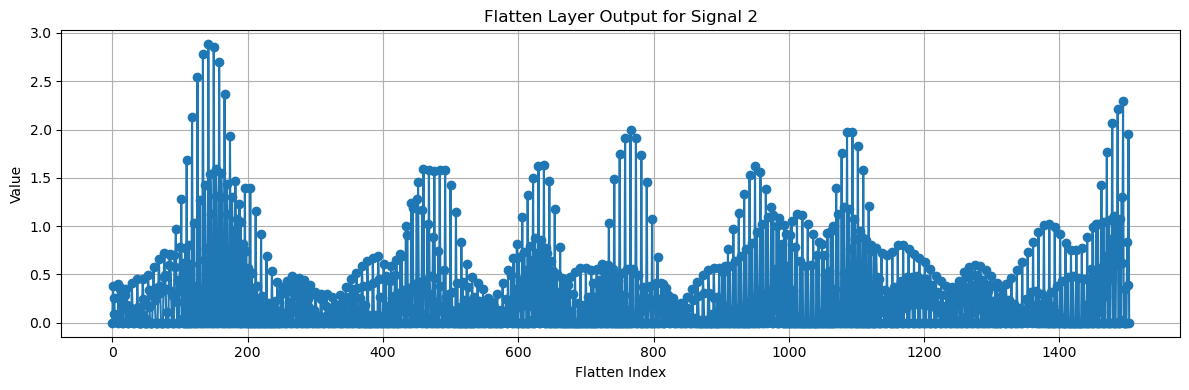

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load flattened outputs from Excel
file_path = "flatten_outputs.xlsx"
df = pd.read_excel(file_path, header=None)

# Ask user to choose a signal number (1 to 10)
signal_number = int(input("Enter the signal number to plot (1 to 10): "))
assert 1 <= signal_number <= 10, "Signal number must be between 1 and 10."

# Select the corresponding row (row 2 to row 11 in Excel → index 1 to 10 in pandas)
row_index = signal_number  # pandas index starts at 0, so row 2 is index 1
flatten_values = df.iloc[row_index].values

# Plot
plt.figure(figsize=(12, 4))
plt.plot(flatten_values, marker='o', linestyle='-')
plt.title(f"Flatten Layer Output for Signal {signal_number}")
plt.xlabel("Flatten Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()

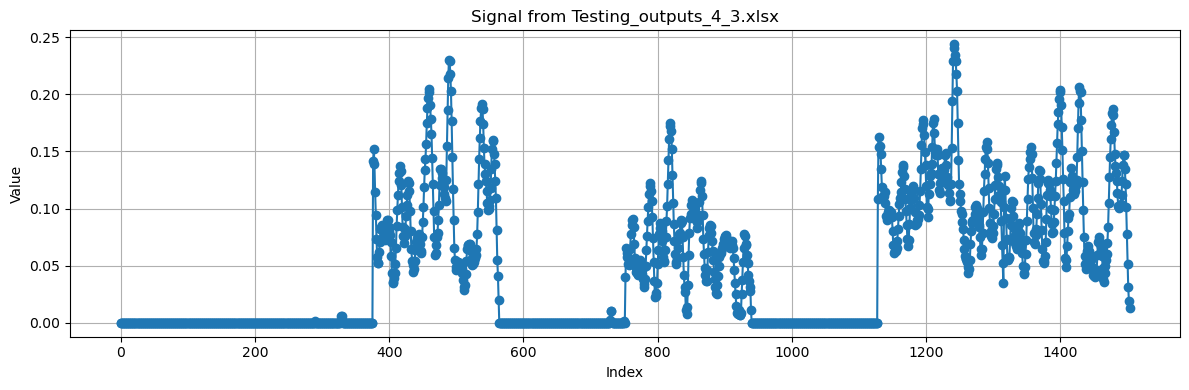

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = "Testing_outputs_4_3.xlsx"
df = pd.read_excel(file_path, header=None)

# Extract the signal (assuming it's in the first column)
signal = df.iloc[:, 0].values

# Ensure that the signal contains only numeric values
signal = pd.to_numeric(signal, errors='coerce')

# Remove NaN values that may have been introduced by non-numeric entries
signal = signal[~pd.isna(signal)]

# Plot the signal
plt.figure(figsize=(12, 4))
plt.plot(signal, marker='o', linestyle='-')
plt.title("Signal from Testing_outputs_4_3.xlsx")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
import numpy as np
import tensorflow as tf
import pandas as pd

# Load the trained model
model = tf.keras.models.load_model("mr_cnn_model.h5")  # Update with correct path

# Get the first convolutional layer (assuming it's the first Conv2D layer)
conv_layer = model.layers[12]  # Change index if needed
filters, biases = conv_layer.get_weights()  # Get filter weights and biases

# Print filter details
print(f"Filter shape: {filters.shape}")  # (kernel_x, kernel_y, input_channels, output_channels)
print(f"Bias shape: {biases.shape}")
print(f"Bias values:\n{biases}")

# Print filter values
num_filters = filters.shape[-1]
# for i in range(num_filters):
#     print(f"\nFilter {i+1} values:\n", filters[:, :, :, i])

# Create a new model that outputs activations of all layers
layer_outputs = [layer.output for layer in model.layers]
activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

# Load the input data (2x200 matrix)
input_file = "signal_2.xlsx"  # Update with correct file path
input_data = pd.read_excel(input_file, header=None)

# Convert to numeric, coercing errors to NaN (to handle any non-numeric values)
input_data = input_data.apply(pd.to_numeric, errors='coerce')

# Drop any rows or columns with NaN values (if they exist after coercion)
input_data = input_data.dropna()

# Ensure the data contains 400 elements (2x200 matrix)
input_data = input_data.values.flatten()  # Flatten to a 1D array
input_data = input_data[:400]  # Take the first 400 elements

# Reshape to (1, 2, 200, 1) assuming the input data is grayscale (1 channel)
input_data = input_data.reshape((1, 2, 200, 1))  # Reshape to (batch_size, height, width, channels)
input_data = input_data.astype(np.float32)  # Ensure the data type is float32

# Get the activations
activations = activation_model.predict(input_data)
model.summary()
# Print the activations of each layer
for i, activation in enumerate(activations):
    # Get the layer name
    layer_name = model.layers[i].name
    print(f"Layer {i} - {layer_name} activation shape: {activation.shape}")
    
    # If the activation is from a Conv2D layer (4D tensor), print the activation maps
    if len(activation.shape) == 4:  # Conv2D layers output 4D data (batch, height, width, channels)
        num_filters = activation.shape[-1]
        size = activation.shape[1]
        
        print(f"Activations for layer {layer_name}:")
        
        # Print activation maps for each filter
        for f in range(num_filters):
            print(f"\nFilter {f+1} output (activation map):")
            print(activation[0, :, :, f])
    else:
        # For other layer types (e.g., Dense layers), just print the activation values
        print(f"Activation values:\n{activation}")


Filter shape: (1, 3, 32, 8)
Bias shape: (8,)
Bias values:
[ 0.04234814  0.04578417  0.00845391  0.02216227 -0.01334618  0.03499986
 -0.04998136  0.03610092]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 2, 200, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 2, 200, 64)        │           1,088 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 1, 197, 32)        │          16,416 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 1, 197, 16)        │           4,112 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 1, 197, 16)        │             528 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 1, 197, 32)        │               0 │ conv2d_2[0][0],            │
│                               │                           │                 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d             │ (None, 1, 195, 32)        │               0 │ concatenate[0][0]          │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 1, 195, 16)        │           1,552 │ average_pooling2d[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 1, 195, 16)        │           2,064 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 1, 195, 16)        │             272 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 1, 195, 32)        │               0 │ conv2d_5[0][0],            │
│                               │                           │                 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ average_pooling2d_1           │ (None, 1, 188, 32)        │               0 │ concatenate_1[0][0]        │
│ (AveragePooling2D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 1, 188, 8)         │             776 │ average_pooling2d_1[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 1504)              │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │         192,640 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 222,646 (869.71 KB)

 Trainable params: 222,644 (869.70 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Layer 0 - input_layer activation shape: (1, 2, 200, 1)
Activations for layer input_layer:

Filter 1 output (activation map):
[[-0.33255586 -0.67947876 -1.3627112   0.4462741   1.28235    -0.29511243
   1.474713   -0.89126384 -1.5462335   0.17356049  0.17587712  1.4736434
  -0.353275   -1.1386818  -0.47122875  1.7244827  -1.4304087  -0.6031274
   2.1109202  -0.05980959 -0.5868878  -0.4206343   1.7882112  -0.48092234
  -3.1606007  -1.630955    1.1667627  -3.0470066  -0.37878025  0.48061794
  -0.6357279   0.2984936  -0.86165     1.6115936   0.1911384   0.22391146
   1.6444215   1.9264926  -0.1456224  -0.13999042  1.8400217  -0.5417106
  -0.2404345   0.15345392  1.7776396   0.489228    0.51963204 -1.7534287
   0.36386082 -0.9275251  -0.79905134 -2.2015269  -0.08299175  2.111823
   1.2638537   2.063985    0.59686065  0.27495265 -0.71898675  0.630938
  -0.32532212 -1.73136     0.6487047  -2.5417242  -0.72301984  1.4548619
  -0.3951295   0.54031163  0.23623861 -0.37653714 -0.9523448  -0.78001